# Retail Market Basket Intelligence: Phase 1 - Exploratory Data Analysis (EDA)

**Author:** Karthik Yelugam | Data Analyst  
**Environment:** Python, Pandas, NumPy, Matplotlib, Seaborn, SQLAlchemy, MySQL  

### 📌 Executive Summary & Phase Objective
This notebook represents **Phase 1** of the Market Basket Intelligence pipeline. The objective is to extract raw transactional data directly from a production MySQL database and perform rigorous exploratory data analysis (EDA). 

**Key Operations Performed:**
1. Secure database connection and data extraction.
2. Structural profiling and schema validation.
3. Data quality assessment (hidden missing values, duplicates, structural anomalies).
4. Statistical distributions and behavioral profiling (basket sizes, top-selling products).

The insights generated here define the transformation logic required for Phase 2 (Data Preprocessing).

In [1]:
# =============================================================================
# 0. IMPORT REQUIRED LIBRARIES & CONFIGURE SETTINGS
# =============================================================================

# Core Data Manipulation
import pandas as pd
import numpy as np

# Database Connectivity
from sqlalchemy import create_engine
import pymysql

# Professional Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Global Pandas Display Settings for Large Datasets
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Enterprise Visualization Theme
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_theme(style="whitegrid", palette="muted")

print("✔ All libraries loaded and environment configured successfully.")

✔ All libraries loaded and environment configured successfully.


---
## 1. Database Connection & Data Extraction
In a production environment, data is extracted from centralized relational databases. Here, we establish a connection using `SQLAlchemy` and load the raw transaction table into a Pandas DataFrame.

In [2]:
# =============================================================================
# 1.1 ESTABLISH SECURE DATABASE CONNECTION
# =============================================================================

# Note: In an enterprise environment, credentials should be loaded via 
# environment variables (e.g., os.getenv("DB_USER")) or a secure vault. 
# For demonstration and pipeline execution purposes, they are defined below.

username = "dm_team16"
password = "2o_hihiFeTRE"
host = "18.136.157.135"
database = "project_purchase_pattern_analysis"

try:
    # Create the SQLAlchemy engine
    engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")
    
    # Execute extraction query
    query = "SELECT * FROM mytable"
    print("Executing extraction query... Please wait.")
    df_raw = pd.read_sql(query, engine)
    
    print(f"✔ Dataset loaded successfully! Total records extracted: {len(df_raw):,}")
    
except Exception as e:
    print(f"❌ Database connection failed: {e}")

Executing extraction query... Please wait.
✔ Dataset loaded successfully! Total records extracted: 522,064


---
## 2. Structural Profiling & Dataset Overview
Understanding the dimensions, data types, and initial schema of the dataset before diving into deep analytics.

In [3]:
# =============================================================================
# 2.1 DIMENSIONALITY & SCHEMA VALIDATION
# =============================================================================

# Create a working copy to preserve the extracted raw state
df = df_raw.copy()

# Display Structural Dimensions
print(f"Dataset Dimensions: {df.shape[0]:,} Rows and {df.shape[1]} Columns")

# Inspect Data Types and Memory Usage
print("\n--- Schema & Data Types ---")
df.info()

# Preview the Top 5 Records to understand data format
display(df.head())

Dataset Dimensions: 522,064 Rows and 7 Columns

--- Schema & Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522064 entries, 0 to 522063
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   BillNo        522064 non-null  object 
 1   Itemname      522064 non-null  object 
 2   Quantity      522064 non-null  int64  
 3   Present_Date  522064 non-null  object 
 4   Price         522064 non-null  float64
 5   CustomerID    522064 non-null  object 
 6   Country       522064 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 27.9+ MB


,BillNo,Itemname,Quantity,Present_Date,Price,CustomerID,Country
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.550,17850,United Kingdom
1,536365,WHITE METAL LANTERN,6,01-12-2010 08:26,3.390,17850,United Kingdom
2,536365,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.750,17850,United Kingdom
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.390,17850,United Kingdom
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.390,17850,United Kingdom


---
## 3. Data Quality & Anomaly Detection
A critical step in data engineering is identifying hidden anomalies. This includes handling missing values masked as empty strings, identifying absolute duplicate records, and finding logical errors (like negative quantities and prices).

In [4]:
# =============================================================================
# 3.1 IDENTIFY HIDDEN MISSING VALUES & CLEAN TEXT FORMATTING
# =============================================================================

# EDA reveals that missing values are often stored as empty strings ("") rather than True NaNs.
# We replace empty strings with np.nan to utilize Pandas' built-in null detection.
df.replace("", np.nan, inplace=True)

# Strip leading/trailing whitespaces from all string (object) columns to prevent grouping errors
str_cols = df.select_dtypes(include=['object']).columns
for col in str_cols:
    df[col] = df[col].str.strip()

# Generate a Comprehensive Missing Value Report
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage (%)": (df.isnull().mean() * 100).round(2)
})

print("--- Missing Value Summary ---")
display(missing_summary[missing_summary["Missing Values"] > 0].sort_values(by="Missing Percentage (%)", ascending=False))

--- Missing Value Summary ---


,Missing Values,Missing Percentage (%)
CustomerID,134041,25.680
Itemname,1455,0.280


In [5]:
# =============================================================================
# 3.2 DETECT DUPLICATES & LOGICAL ANOMALIES
# =============================================================================

# 1. Exact Duplicate Records
total_duplicates = df.duplicated().sum()

# 2. Logical Anomalies: Negative or Zero Quantities (Returns / Errors)
invalid_qty = (df['Quantity'] <= 0).sum()

# 3. Logical Anomalies: Invalid Pricing (Zero or Negative Prices)
invalid_price = (df['Price'] <= 0).sum()

print("--- Data Anomaly Report ---")
print(f"Exact Duplicate Rows Detected : {total_duplicates:,}")
print(f"Invalid/Negative Quantities   : {invalid_qty:,}")
print(f"Invalid/Zero Prices Detected  : {invalid_price:,}")

--- Data Anomaly Report ---
Exact Duplicate Rows Detected : 5,286
Invalid/Negative Quantities   : 1,336
Invalid/Zero Prices Detected  : 2,513


---
## 4. Statistical Summaries & Cardinality
Analyzing the central tendency and spread of numerical features (`Quantity`, `Price`) and the unique cardinality of categorical features.

In [6]:
# =============================================================================
# 4.1 DESCRIPTIVE STATISTICS
# =============================================================================

# Generate descriptive statistics for numerical columns
print("--- Numerical Distributions ---")
display(df[['Quantity', 'Price']].describe())

# Check the unique cardinality of categorical/identifier columns
print("\n--- Unique Entity Counts (Cardinality) ---")
cardinality = df.nunique().to_frame(name="Unique Count")
display(cardinality)

--- Numerical Distributions ---


,Quantity,Price
count,522064.000,522064.000
mean,10.090,3.827
std,161.111,41.901
min,-9600.000,-11062.060
25%,1.000,1.250
50%,3.000,2.080
75%,10.000,4.130
max,80995.000,13541.330



--- Unique Entity Counts (Cardinality) ---


,Unique Count
BillNo,21663
Itemname,4185
Quantity,690
Present_Date,19641
Price,1285
CustomerID,4297
Country,30


---
## 5. Behavioral & Geographic Profiling
Visualizing business-critical metrics to understand customer behavior: 
1. Top Volume Products
2. Geographic Transaction Distribution
3. Transaction Basket Size

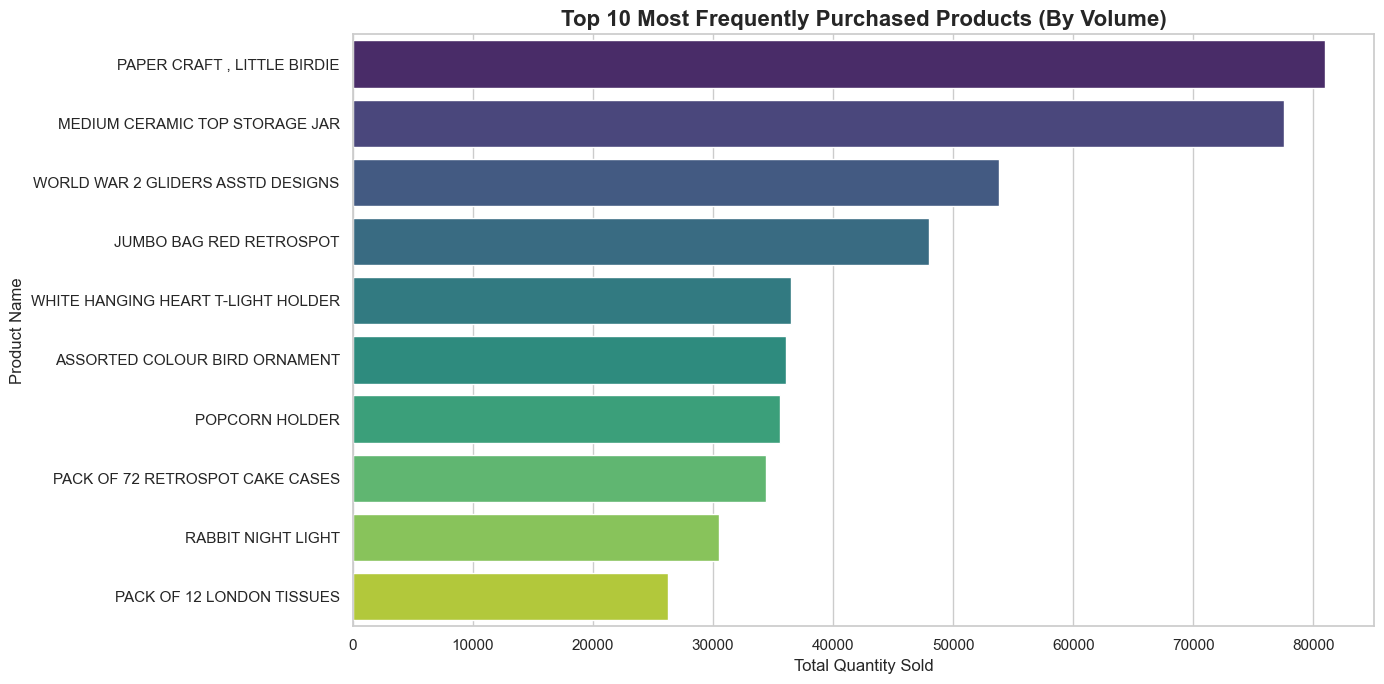

In [7]:
# =============================================================================
# 5.1 TOP 10 HIGH-VOLUME PRODUCTS
# =============================================================================

# Filter out missing items and negative quantities (returns)
valid_sales = df[(df['Quantity'] > 0) & (df['Itemname'].notnull())]

# Aggregate total quantity sold per product
top_products = valid_sales.groupby('Itemname')['Quantity'].sum().sort_values(ascending=False).head(10)

# Plotting the Insights
plt.figure(figsize=(14, 7))
sns.barplot(
    x=top_products.values, 
    y=top_products.index, 
    hue=top_products.index,   # Set to resolve Seaborn v0.14.0+ warnings
    palette="viridis",
    legend=False
)
plt.title("Top 10 Most Frequently Purchased Products (By Volume)", fontsize=16, fontweight="bold")
plt.xlabel("Total Quantity Sold", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.tight_layout()
plt.show()

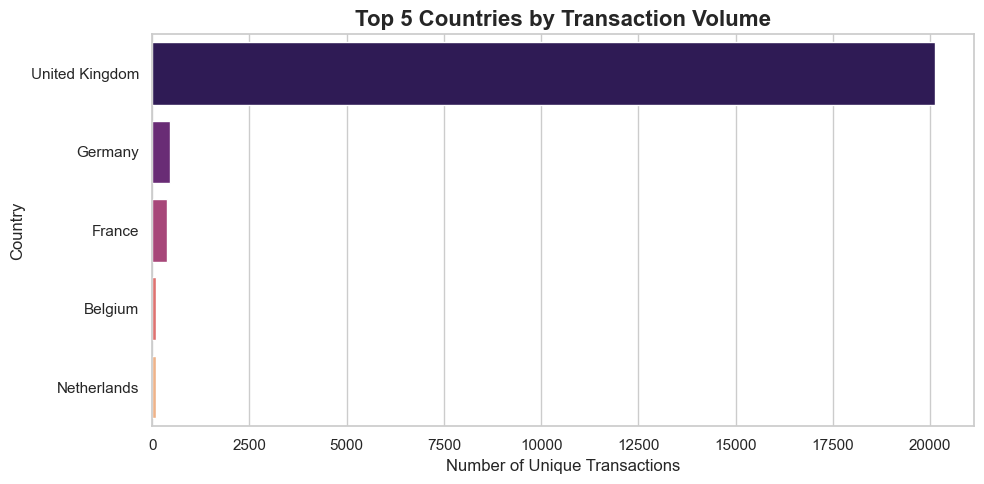

In [8]:
# =============================================================================
# 5.2 GEOGRAPHIC TRANSACTION DISTRIBUTION
# =============================================================================

# Count total unique transactions (BillNo) per country
top_countries = df.groupby('Country')['BillNo'].nunique().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    hue=top_countries.index,  # Set to resolve Seaborn v0.14.0+ warnings
    palette="magma",
    legend=False
)
plt.title("Top 5 Countries by Transaction Volume", fontsize=16, fontweight="bold")
plt.xlabel("Number of Unique Transactions", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.tight_layout()
plt.show()

--- Transaction Basket Size Summary ---
Minimum Items in a Basket : 1
Average Items in a Basket : 26.36
Maximum Items in a Basket : 1114


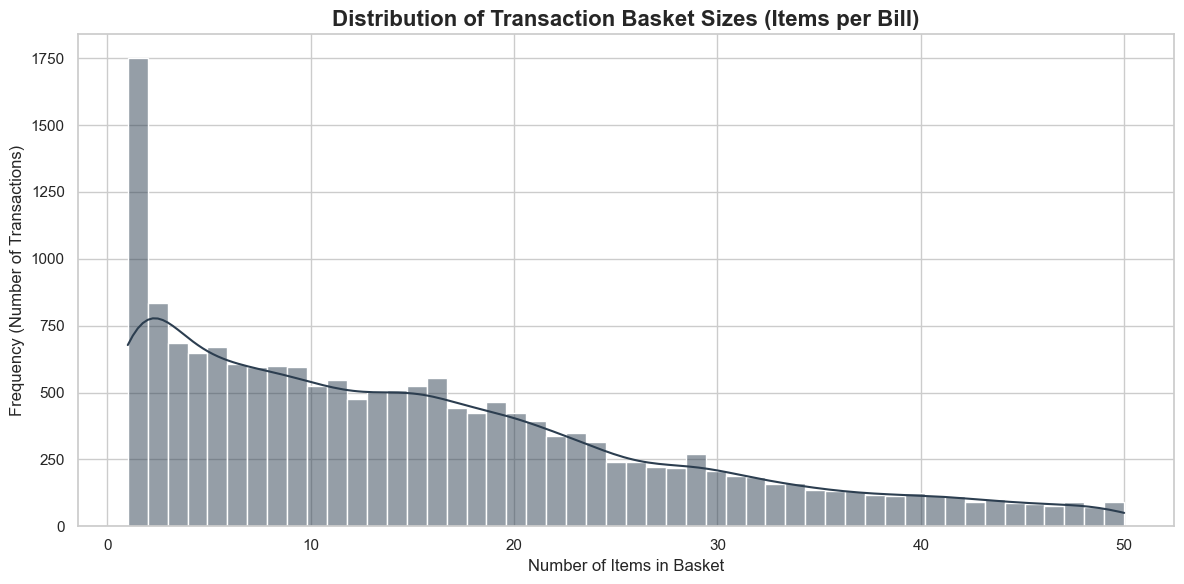

In [9]:
# =============================================================================
# 5.3 TRANSACTION BASKET SIZE ANALYSIS
# =============================================================================

# Calculate how many unique items are in each transaction (basket)
basket_sizes = valid_sales.groupby('BillNo')['Itemname'].count()

print("--- Transaction Basket Size Summary ---")
print(f"Minimum Items in a Basket : {basket_sizes.min()}")
print(f"Average Items in a Basket : {basket_sizes.mean():.2f}")
print(f"Maximum Items in a Basket : {basket_sizes.max()}")

# Plotting the distribution of basket sizes (Capping at 50 for readability)
plt.figure(figsize=(12, 6))
sns.histplot(basket_sizes[basket_sizes <= 50], bins=50, kde=True, color="#2c3e50")
plt.title("Distribution of Transaction Basket Sizes (Items per Bill)", fontsize=16, fontweight="bold")
plt.xlabel("Number of Items in Basket", fontsize=12)
plt.ylabel("Frequency (Number of Transactions)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 🎯 Phase 1 Conclusion & Key Takeaways

The Exploratory Data Analysis reveals critical insights necessary for the next phase of the pipeline:
1. **Missing Data:** Significant missing values in `CustomerID` (~25.6%) and `Itemname`. Since Market Basket Analysis relies entirely on `BillNo` and `Itemname`, careful handling is required.
2. **Data Noise:** The dataset contains absolute duplicates and logical anomalies (negative quantities implying returns, and invalid pricing). These must be stripped out to avoid skewing the Apriori algorithms.
3. **Outliers:** The descriptive statistics reveal extreme outliers in `Quantity` and `Price`, suggesting bulk purchases or system entry errors.
4. **Behavioral Patterns:** The vast majority of transaction baskets contain between 1 and 20 items, providing an excellent foundation for Association Rule Mining.

**Next Steps:** Proceed to `02_data_preprocessing_and_feature_engineering.ipynb` to execute the rigorous data cleaning pipeline and transform this raw dataset into a sparse Boolean Basket Matrix.